# 07 - Model Training and Candidate Selection

## Objective

Train and compare four baseline classifiers, deeply tune the three trainable
algorithms, and select one candidate model for final holdout evaluation.

The four baselines are:

1. Majority Class Baseline.
2. Logistic Regression.
3. Random Forest.
4. XGBoost.

The majority baseline is a reference rule and has no hyperparameters to tune.
Logistic Regression, Random Forest, and XGBoost are tuned with five expanding
chronological folds. Accuracy is reported but is not the primary criterion
because delayed flights are the minority class.


## Scope Boundary

- **Training period:** January-August 2025.
- **Validation period:** September-October 2025.
- **Holdout period:** November-December 2025.

The holdout outcomes are not used for preprocessing, tuning, threshold
selection, or candidate-model selection in this notebook. Notebook 08 performs
the one-time holdout evaluation.

Historical delay-rate features are reconstructed inside every chronological
fold. Training rows use only earlier dates, and validation rows use history
learned only from that fold's training period.


## Load Project Configuration


In [25]:
import importlib.util
import os
from pathlib import Path

bootstrap = Path.cwd() / "notebooks" / "import_path.py"
if not bootstrap.is_file():
    bootstrap = Path.cwd() / "import_path.py"

spec = importlib.util.spec_from_file_location("import_path", bootstrap)
import_path = importlib.util.module_from_spec(spec)
spec.loader.exec_module(import_path)

from config import project_config as cfg

try:
    spark
except NameError:
    from databricks.connect import DatabricksSession

    databricks_profile = os.getenv(
        "DATABRICKS_CONFIG_PROFILE", "capstone-serverless"
    )
    spark = (
        DatabricksSession.builder
        .serverless()
        .profile(databricks_profile)
        .getOrCreate()
    )

print("Project configuration and Spark session loaded successfully.")


Project configuration and Spark session loaded successfully.


## Import Standard-Python Modeling Libraries


In [26]:
import io
import json
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.calibration import calibration_curve
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    PrecisionRecallDisplay,
    RocCurveDisplay,
)
from sklearn.model_selection import ParameterSampler

from utils.python_model_training import (
    best_cv_row,
    build_estimator,
    choose_operational_threshold,
    classification_metrics,
    fit_and_score,
    logistic_refinements,
    parameters_json,
    prepare_model_matrices,
    random_forest_refinements,
    run_cv_search,
    select_final_candidate,
    shortlist_cv_candidates,
    xgboost_refinements,
)

warnings.filterwarnings("ignore", category=FutureWarning)
pd.set_option("display.max_colwidth", 120)
pd.set_option("display.max_columns", 30)

print("Standard-Python modeling libraries loaded successfully.")


Standard-Python modeling libraries loaded successfully.


## Load and Validate the Feature Dataset


In [27]:
from pyspark.sql import DataFrame
from pyspark.sql import functions as F
from pyspark.sql import types as T
from pyspark.sql.window import Window

FEATURE_TABLE = cfg.FEATURES_TABLE
TARGET_COLUMN = cfg.TARGET_COLUMN
DATE_COLUMN = cfg.FLIGHT_DATE_COLUMN
MODEL_COLUMNS = list(cfg.PYTHON_MODEL_INPUT_COLUMNS)

if not spark.catalog.tableExists(FEATURE_TABLE):
    raise RuntimeError(
        f"Required table '{FEATURE_TABLE}' was not found. "
        "Run Notebook 06 before continuing."
    )

df_features: DataFrame = spark.table(FEATURE_TABLE)
required_columns = (
    set(MODEL_COLUMNS + [TARGET_COLUMN, DATE_COLUMN])
    - set(cfg.MODEL_HISTORICAL_RATE_COLUMNS)
)
missing_columns = sorted(required_columns - set(df_features.columns))
if missing_columns:
    raise ValueError(f"Missing required columns: {missing_columns}")

if not isinstance(df_features.schema[DATE_COLUMN].dataType, T.DateType):
    raise TypeError(f"{DATE_COLUMN} must be a Spark date column.")

invalid_target_count = df_features.filter(
    F.col(DATE_COLUMN) <= F.lit(cfg.VALIDATION_END_DATE)
).filter(
    F.col(TARGET_COLUMN).isNull() | ~F.col(TARGET_COLUMN).isin(0.0, 1.0)
).count()
if invalid_target_count:
    raise ValueError(f"Invalid target rows: {invalid_target_count:,}")

print(f"Source table: {FEATURE_TABLE}")
print(f"Model inputs: {len(MODEL_COLUMNS)}")
print(f"Target: {TARGET_COLUMN}")


Source table: workspace.default.flights_features
Model inputs: 19
Target: ARR_DEL15


## Create Chronological Development Periods


In [28]:
df_train = df_features.filter(F.col(DATE_COLUMN) <= F.lit(cfg.TRAIN_END_DATE))
df_validation = df_features.filter(
    (F.col(DATE_COLUMN) >= F.lit(cfg.VALIDATION_START_DATE))
    & (F.col(DATE_COLUMN) <= F.lit(cfg.VALIDATION_END_DATE))
)
df_holdout = df_features.filter(F.col(DATE_COLUMN) >= F.lit(cfg.TEST_START_DATE))

development_summary = (
    df_train.withColumn("SPLIT", F.lit("Training"))
    .unionByName(df_validation.withColumn("SPLIT", F.lit("Validation")))
    .groupBy("SPLIT")
    .agg(
        F.count("*").alias("TOTAL_FLIGHTS"),
        F.sum(TARGET_COLUMN).cast("long").alias("DELAYED_FLIGHTS"),
    )
    .withColumn(
        "DELAYED_PCT",
        F.round(F.col("DELAYED_FLIGHTS") / F.col("TOTAL_FLIGHTS") * 100, 2),
    )
)
holdout_summary = df_holdout.agg(
    F.count("*").alias("TOTAL_FLIGHTS")
).select(
    F.lit("Holdout test (sealed)").alias("SPLIT"),
    "TOTAL_FLIGHTS",
    F.lit(None).cast("long").alias("DELAYED_FLIGHTS"),
    F.lit(None).cast("double").alias("DELAYED_PCT"),
)
split_summary = development_summary.unionByName(holdout_summary)

display(split_summary)


,SPLIT,TOTAL_FLIGHTS,DELAYED_FLIGHTS,DELAYED_PCT
0,Training,4592366,1052245.0,22.91
1,Validation,1159898,215110.0,18.55
2,Holdout test (sealed),1127219,NaN,NaN


### Class-Balance Interpretation

The real class distribution is preserved in validation data. Holdout labels
remain sealed. A
model that predicts every flight as on time can still obtain high accuracy,
so the comparison emphasizes delayed-flight precision, recall and F1, PR-AUC,
ROC-AUC, Brier score, the confusion matrix, and Top-10% lift/recall.

Any class-imbalance treatment is learned only from training data. The primary
comparison tests the natural distribution and class weighting; it does not
discard flights through undersampling.


## Define Leakage-Safe Historical Rates


In [29]:
HISTORY_SPECS = [
    ("AIRLINE_HIST_DELAY_RATE", [cfg.AIRLINE_COLUMN]),
    ("ORIGIN_HIST_DELAY_RATE", [cfg.ORIGIN_COLUMN]),
    ("DEST_HIST_DELAY_RATE", [cfg.DESTINATION_COLUMN]),
    (
        "ROUTE_HIST_DELAY_RATE",
        [cfg.ORIGIN_COLUMN, cfg.DESTINATION_COLUMN],
    ),
]
HISTORY_COLUMNS = [item[0] for item in HISTORY_SPECS]
SMOOTHING = float(cfg.HISTORICAL_SMOOTHING_STRENGTH)
INITIAL_PRIOR = float(cfg.HISTORICAL_INITIAL_PRIOR_RATE)


def attach_expanding_training_history(
    history_source: DataFrame,
    rows_to_score: DataFrame,
) -> DataFrame:
    """Use only dates strictly earlier than each training row."""
    global_daily = history_source.groupBy(DATE_COLUMN).agg(
        F.count("*").alias("GLOBAL_DAILY_FLIGHTS"),
        F.sum(TARGET_COLUMN).alias("GLOBAL_DAILY_DELAYS"),
    )
    global_window = (
        Window.orderBy(DATE_COLUMN)
        .rowsBetween(Window.unboundedPreceding, -1)
    )
    global_history = (
        global_daily
        .withColumn(
            "GLOBAL_PRIOR_FLIGHTS",
            F.sum("GLOBAL_DAILY_FLIGHTS").over(global_window),
        )
        .withColumn(
            "GLOBAL_PRIOR_DELAYS",
            F.sum("GLOBAL_DAILY_DELAYS").over(global_window),
        )
        .withColumn(
            "GLOBAL_PRIOR_RATE",
            F.coalesce(
                F.col("GLOBAL_PRIOR_DELAYS") / F.col("GLOBAL_PRIOR_FLIGHTS"),
                F.lit(INITIAL_PRIOR),
            ),
        )
        .select(DATE_COLUMN, "GLOBAL_PRIOR_RATE")
    )

    scored = rows_to_score.join(global_history, DATE_COLUMN, "left")
    for output_column, group_columns in HISTORY_SPECS:
        daily_flights = f"{output_column}_DAILY_FLIGHTS"
        daily_delays = f"{output_column}_DAILY_DELAYS"
        prior_flights = f"{output_column}_PRIOR_FLIGHTS"
        prior_delays = f"{output_column}_PRIOR_DELAYS"

        daily = history_source.groupBy(DATE_COLUMN, *group_columns).agg(
            F.count("*").alias(daily_flights),
            F.sum(TARGET_COLUMN).alias(daily_delays),
        )
        group_window = (
            Window.partitionBy(*group_columns)
            .orderBy(DATE_COLUMN)
            .rowsBetween(Window.unboundedPreceding, -1)
        )
        rates = (
            daily
            .withColumn(prior_flights, F.sum(daily_flights).over(group_window))
            .withColumn(prior_delays, F.sum(daily_delays).over(group_window))
            .join(global_history, DATE_COLUMN, "left")
            .withColumn(
                output_column,
                (
                    F.coalesce(F.col(prior_delays), F.lit(0.0))
                    + SMOOTHING * F.col("GLOBAL_PRIOR_RATE")
                )
                /
                (
                    F.coalesce(F.col(prior_flights), F.lit(0.0))
                    + F.lit(SMOOTHING)
                ),
            )
            .select(DATE_COLUMN, *group_columns, output_column)
        )
        scored = scored.join(
            rates,
            [DATE_COLUMN, *group_columns],
            "left",
        )

    return scored.drop("GLOBAL_PRIOR_RATE")


def attach_fixed_validation_history(
    training_history: DataFrame,
    rows_to_score: DataFrame,
) -> DataFrame:
    """Use only aggregated outcomes from the preceding training period."""
    global_rate = float(
        training_history.agg(F.avg(TARGET_COLUMN).alias("RATE")).first()["RATE"]
    )
    scored = rows_to_score
    for output_column, group_columns in HISTORY_SPECS:
        group_history = (
            training_history.groupBy(*group_columns)
            .agg(
                F.count("*").alias("HIST_FLIGHTS"),
                F.sum(TARGET_COLUMN).alias("HIST_DELAYS"),
            )
            .withColumn(
                output_column,
                (
                    F.col("HIST_DELAYS") + SMOOTHING * F.lit(global_rate)
                )
                / (F.col("HIST_FLIGHTS") + F.lit(SMOOTHING)),
            )
            .select(*group_columns, output_column)
        )
        scored = scored.join(group_history, group_columns, "left").fillna(
            {output_column: global_rate}
        )
    return scored

print("Leakage-safe historical-rate functions defined.")


Leakage-safe historical-rate functions defined.


Historical rates use additive smoothing with the preceding training period's
overall delay rate. The value 0.50 is used only on the first training date,
when no earlier outcome exists; it is a neutral Bernoulli prior, not an added
half-delay and not a value repeatedly added to later rates.


## Define Uniform Sampling and Fold Preparation


In [30]:
CATEGORICAL_COLUMNS = list(cfg.PYTHON_MODEL_CATEGORICAL_COLUMNS)
NUMERICAL_COLUMNS = list(cfg.PYTHON_MODEL_NUMERICAL_COLUMNS)
OUTPUT_COLUMNS = MODEL_COLUMNS + [TARGET_COLUMN]


def uniform_sample(frame: DataFrame, maximum_rows: int, seed: int) -> DataFrame:
    """Bound runtime without changing the natural class distribution."""
    row_count = frame.count()
    if row_count <= maximum_rows:
        return frame
    fraction = min(1.0, maximum_rows / row_count * 1.08)
    return frame.sample(False, fraction, seed).limit(maximum_rows)


def prepare_period_pair(
    training_frame: DataFrame,
    validation_frame: DataFrame,
    maximum_training_rows: int,
    maximum_validation_rows: int,
    seed: int,
    label: str,
) -> tuple[pd.DataFrame, pd.DataFrame]:
    sampled_train = uniform_sample(training_frame, maximum_training_rows, seed)
    sampled_validation = uniform_sample(
        validation_frame, maximum_validation_rows, seed + 1
    )

    train_with_history = attach_expanding_training_history(
        training_frame, sampled_train
    ).select(*OUTPUT_COLUMNS)
    validation_with_history = attach_fixed_validation_history(
        training_frame, sampled_validation
    ).select(*OUTPUT_COLUMNS)

    train_pdf = train_with_history.toPandas()
    validation_pdf = validation_with_history.toPandas()
    print(
        f"{label}: train={len(train_pdf):,} "
        f"({train_pdf[TARGET_COLUMN].mean():.2%} delayed), "
        f"validation={len(validation_pdf):,} "
        f"({validation_pdf[TARGET_COLUMN].mean():.2%} delayed)"
    )
    return train_pdf, validation_pdf


## Prepare the Five Expanding Chronological Folds


In [31]:
fold_rows = []
prepared_folds = []

for fold_number, fold in enumerate(cfg.TUNING_FOLDS, start=1):
    fold_train = df_features.filter(
        (F.col(DATE_COLUMN) >= F.lit(fold["train_start"]))
        & (F.col(DATE_COLUMN) <= F.lit(fold["train_end"]))
    )
    fold_validation = df_features.filter(
        (F.col(DATE_COLUMN) >= F.lit(fold["validation_start"]))
        & (F.col(DATE_COLUMN) <= F.lit(fold["validation_end"]))
    )

    train_pdf, validation_pdf = prepare_period_pair(
        training_frame=fold_train,
        validation_frame=fold_validation,
        maximum_training_rows=cfg.TUNING_MAX_TRAIN_ROWS,
        maximum_validation_rows=cfg.TUNING_MAX_VALIDATION_ROWS,
        seed=cfg.RANDOM_SEED + fold_number * 10,
        label=fold["fold"],
    )
    prepared = prepare_model_matrices(
        train_frame=train_pdf,
        validation_frame=validation_pdf,
        categorical_columns=CATEGORICAL_COLUMNS,
        numerical_columns=NUMERICAL_COLUMNS,
        target_column=TARGET_COLUMN,
    )
    prepared["fold_name"] = fold["fold"]
    prepared_folds.append(prepared)
    fold_rows.append(fold)

display(pd.DataFrame(fold_rows))
print(f"Prepared chronological folds: {len(prepared_folds)}")


/Users/daniel.montero/Documents/Master of Data Analytics/UNFC Term 5 Capstone/AI-Powered-Flight-Delay-Risk-Prediction-and-Operational-Prioritization/.venv/lib/python3.12/site-packages/pyspark/sql/connect/expressions.py:1134: UserWarning: WARN WindowExpression: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
  warnings.warn(


Fold 1: train=80,000 (19.49% delayed), validation=30,000 (20.13% delayed)


/Users/daniel.montero/Documents/Master of Data Analytics/UNFC Term 5 Capstone/AI-Powered-Flight-Delay-Risk-Prediction-and-Operational-Prioritization/.venv/lib/python3.12/site-packages/pyspark/sql/connect/expressions.py:1134: UserWarning: WARN WindowExpression: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
  warnings.warn(


Fold 2: train=80,000 (19.17% delayed), validation=30,000 (23.57% delayed)


/Users/daniel.montero/Documents/Master of Data Analytics/UNFC Term 5 Capstone/AI-Powered-Flight-Delay-Risk-Prediction-and-Operational-Prioritization/.venv/lib/python3.12/site-packages/pyspark/sql/connect/expressions.py:1134: UserWarning: WARN WindowExpression: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
  warnings.warn(


...

Fold 4: train=80,000 (22.06% delayed), validation=30,000 (28.80% delayed)


/Users/daniel.montero/Documents/Master of Data Analytics/UNFC Term 5 Capstone/AI-Powered-Flight-Delay-Risk-Prediction-and-Operational-Prioritization/.venv/lib/python3.12/site-packages/pyspark/sql/connect/expressions.py:1134: UserWarning: WARN WindowExpression: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
  warnings.warn(


Fold 5: train=80,000 (22.71% delayed), validation=30,000 (22.74% delayed)


,fold,train_start,train_end,validation_start,validation_end
0,Fold 1,2025-01-01,2025-03-31,2025-04-01,2025-04-30
1,Fold 2,2025-01-01,2025-04-30,2025-05-01,2025-05-31
2,Fold 3,2025-01-01,2025-05-31,2025-06-01,2025-06-30
3,Fold 4,2025-01-01,2025-06-30,2025-07-01,2025-07-31
4,Fold 5,2025-01-01,2025-07-31,2025-08-01,2025-08-31


Prepared chronological folds: 5


### Why this is Cross-Validation

Each configuration is trained and evaluated five times. Fold 1 trains on
January-March and validates on April; every following fold expands the past
training window by one month and validates on the next unseen month. This is
time-series cross-validation—not a random K-fold split.

The transformed matrices are prepared once per fold and reused by every
configuration. This removes the repeated Spark work that made earlier versions
take many hours while preserving all five folds.


## Prepare the Main Training and Validation Samples


In [32]:
confirmation_train_pdf, confirmation_validation_pdf = prepare_period_pair(
    training_frame=df_train,
    validation_frame=df_validation,
    maximum_training_rows=cfg.CONFIRMATION_MAX_TRAIN_ROWS,
    maximum_validation_rows=cfg.CONFIRMATION_MAX_VALIDATION_ROWS,
    seed=cfg.RANDOM_SEED + 500,
    label="January-August versus September-October",
)
confirmation_data = prepare_model_matrices(
    train_frame=confirmation_train_pdf,
    validation_frame=confirmation_validation_pdf,
    categorical_columns=CATEGORICAL_COLUMNS,
    numerical_columns=NUMERICAL_COLUMNS,
    target_column=TARGET_COLUMN,
)

print(f"Encoded training shape: {confirmation_data['x_train'].shape}")
print(f"Encoded validation shape: {confirmation_data['x_validation'].shape}")


/Users/daniel.montero/Documents/Master of Data Analytics/UNFC Term 5 Capstone/AI-Powered-Flight-Delay-Risk-Prediction-and-Operational-Prioritization/.venv/lib/python3.12/site-packages/pyspark/sql/connect/expressions.py:1134: UserWarning: WARN WindowExpression: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
  warnings.warn(


January-August versus September-October: train=500,000 (22.95% delayed), validation=250,000 (18.64% delayed)
Encoded training shape: (500000, 699)
Encoded validation shape: (250000, 699)


## Train the Four Baseline Models


All baselines use their standard settings and a 0.50 threshold. They answer a
simple question: how much does each algorithm learn before tuning? The baseline
results are not used to select the final model.


In [33]:
baseline_configurations = {
    "Logistic Regression": {
        "C": 1.0,
        "penalty": "l2",
        "imbalance_strategy": "natural",
    },
    "Random Forest": {
        "n_estimators": 250,
        "max_depth": None,
        "min_samples_split": 2,
        "min_samples_leaf": 1,
        "max_features": "sqrt",
        "imbalance_strategy": "natural",
    },
    "XGBoost": {
        "n_estimators": 350,
        "max_depth": 5,
        "learning_rate": 0.05,
        "min_child_weight": 1,
        "subsample": 0.85,
        "colsample_bytree": 0.85,
        "gamma": 0.0,
        "reg_alpha": 0.0,
        "reg_lambda": 1.0,
        "imbalance_strategy": "natural",
    },
}

baseline_rows = []
baseline_probabilities = {}
training_prevalence = float(confirmation_data["y_train"].mean())
majority_probabilities = np.full(
    len(confirmation_data["y_validation"]), training_prevalence
)
majority_metrics = classification_metrics(
    confirmation_data["y_validation"], majority_probabilities, 0.50
)
baseline_rows.append(
    {
        "MODEL": "Majority Class Baseline",
        "PARAMETERS": "Always predicts the training-period majority class",
        "DECISION_THRESHOLD": 0.50,
        "TRAINING_SECONDS": 0.0,
        **majority_metrics,
    }
)
baseline_probabilities["Majority Class Baseline"] = majority_probabilities

for model_name, parameters in baseline_configurations.items():
    _, probabilities, metrics, converged, seconds = fit_and_score(
        model_name=model_name,
        parameters=parameters,
        prepared_data=confirmation_data,
        threshold=0.50,
        random_seed=cfg.RANDOM_SEED,
    )
    baseline_rows.append(
        {
            "MODEL": f"{model_name} Baseline",
            "PARAMETERS": parameters_json(parameters),
            "DECISION_THRESHOLD": 0.50,
            "TRAINING_SECONDS": seconds,
            "CONVERGED": converged,
            **metrics,
        }
    )
    baseline_probabilities[f"{model_name} Baseline"] = probabilities

baseline_results = pd.DataFrame(baseline_rows).sort_values(
    "PR_AUC", ascending=False
)
display(baseline_results)


,MODEL,PARAMETERS,DECISION_THRESHOLD,TRAINING_SECONDS,ACCURACY,DELAY_PRECISION,DELAY_RECALL,DELAY_F1,ROC_AUC,PR_AUC,BRIER_SCORE,TOP_10_RECALL,TOP_10_LIFT,ALERT_RATE,TN,FP,FN,TP,CONVERGED
3,XGBoost Baseline,"{""colsample_bytree"": 0.85, ""gamma"": 0.0, ""imbalance_strategy"": ""natural"", ""learning_rate"": 0.05, ""max_depth"": 5, ""mi...",0.5,1.636347,0.813512,0.491042,0.012940,0.025215,0.670061,0.305881,0.144003,0.194442,1.944421,0.004912,202775,625,45997,603,True
2,Random Forest Baseline,"{""imbalance_strategy"": ""natural"", ""max_depth"": null, ""max_features"": ""sqrt"", ""min_samples_leaf"": 1, ""min_samples_spl...",0.5,476.402517,0.806796,0.362756,0.048240,0.085156,0.653403,0.282052,0.149460,0.178884,1.788841,0.024788,199451,3949,44352,2248,True
1,Logistic Regression Baseline,"{""C"": 1.0, ""imbalance_strategy"": ""natural"", ""penalty"": ""l2""}",0.5,5.736670,0.807156,0.360953,0.044871,0.079820,0.652411,0.281691,0.151525,0.178262,1.782618,0.023172,199698,3702,44509,2091,True
0,Majority Class Baseline,Always predicts the training-period majority class,0.5,0.000000,0.813600,0.000000,0.000000,0.000000,0.500000,0.186400,0.153515,0.068090,0.680901,0.000000,203400,0,46600,0,NaN


## Baseline Confusion Matrices


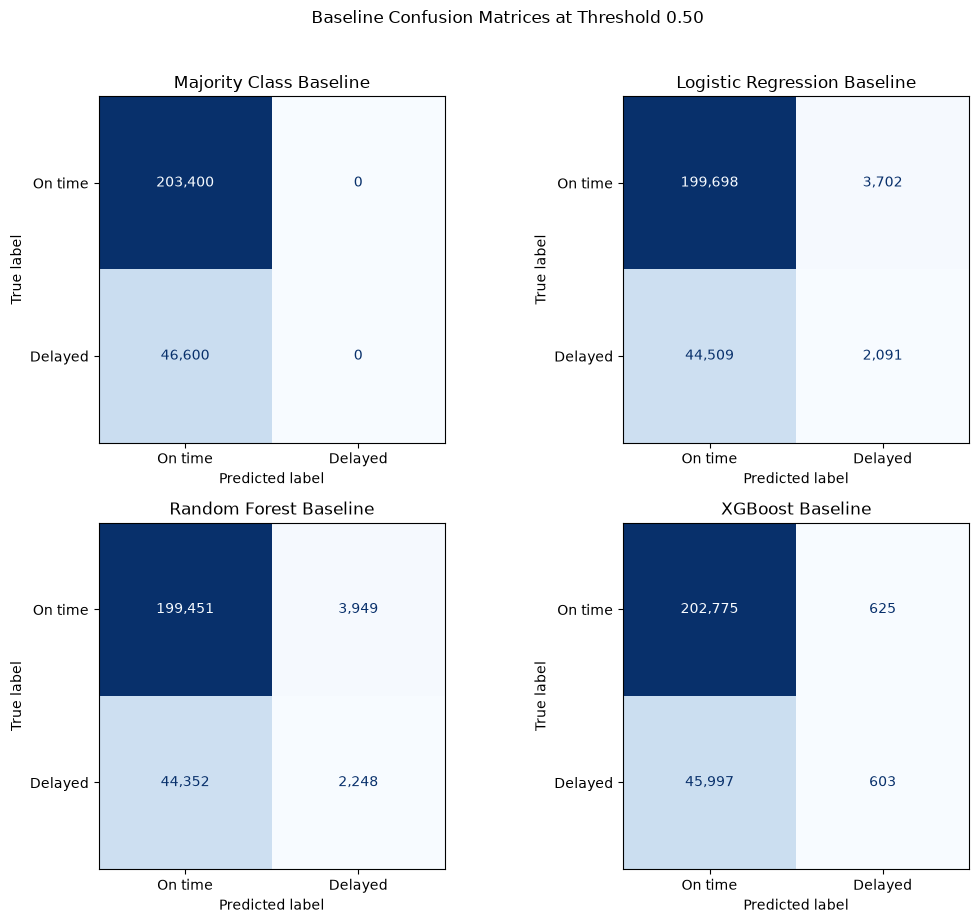

In [34]:
figure, axes = plt.subplots(2, 2, figsize=(11, 9))
labels = confirmation_data["y_validation"]
for axis, (model_name, probabilities) in zip(
    axes.ravel(), baseline_probabilities.items()
):
    predictions = (probabilities >= 0.50).astype(int)
    ConfusionMatrixDisplay.from_predictions(
        labels,
        predictions,
        display_labels=["On time", "Delayed"],
        cmap="Blues",
        colorbar=False,
        values_format=",d",
        ax=axis,
    )
    axis.set_title(model_name)
figure.suptitle("Baseline Confusion Matrices at Threshold 0.50", y=1.02)
figure.tight_layout()
plt.show()


## Deep-Tuning Design


A reproducible randomized broad search explores materially different regions
of each algorithm's parameter space. A smaller focused search then tests values
around that algorithm's broad-search leader. Every broad and refined
configuration is evaluated on all five chronological folds.

Both the natural class distribution and class weighting are candidate
strategies. Weighting changes the cost of minority-class errors; it does not
duplicate or delete records. The same operational threshold rule is applied to
every configuration.


In [35]:
logistic_space = {
    "C": np.logspace(-3, 1, 12).tolist(),
    "penalty": ["l1", "l2"],
    "imbalance_strategy": ["natural", "weighted"],
}
random_forest_space = {
    "n_estimators": [150, 250, 400],
    "max_depth": [8, 12, 16, None],
    "min_samples_split": [2, 10, 30],
    "min_samples_leaf": [1, 5, 20],
    "max_features": ["sqrt", 0.5],
    "imbalance_strategy": ["natural", "weighted"],
}
xgboost_space = {
    "n_estimators": [200, 350, 500],
    "max_depth": [3, 5, 7, 9],
    "learning_rate": [0.03, 0.05, 0.10, 0.15],
    "min_child_weight": [1, 5, 10],
    "subsample": [0.70, 0.85, 1.00],
    "colsample_bytree": [0.70, 0.85, 1.00],
    "gamma": [0.0, 0.10, 0.30],
    "reg_alpha": [0.0, 0.01, 0.10],
    "reg_lambda": [1.0, 3.0, 10.0],
    "imbalance_strategy": ["natural", "weighted"],
}

logistic_broad = list(
    ParameterSampler(
        logistic_space,
        n_iter=cfg.LOGISTIC_BROAD_SEARCH_SIZE,
        random_state=cfg.RANDOM_SEED,
    )
)
random_forest_broad = list(
    ParameterSampler(
        random_forest_space,
        n_iter=cfg.RANDOM_FOREST_BROAD_SEARCH_SIZE,
        random_state=cfg.RANDOM_SEED + 1,
    )
)
xgboost_broad = list(
    ParameterSampler(
        xgboost_space,
        n_iter=cfg.XGBOOST_BROAD_SEARCH_SIZE,
        random_state=cfg.RANDOM_SEED + 2,
    )
)

def unevaluated_refinements(candidates, broad_candidates, required_count):
    broad_keys = {parameters_json(item) for item in broad_candidates}
    filtered = [
        item for item in candidates if parameters_json(item) not in broad_keys
    ]
    if len(filtered) < required_count:
        raise RuntimeError(
            f"Only {len(filtered)} unique refinement configurations were generated; "
            f"{required_count} are required."
        )
    return filtered[:required_count]


search_summary = pd.DataFrame(
    [
        {
            "MODEL": "Logistic Regression",
            "BROAD": len(logistic_broad),
            "REFINEMENT": cfg.LOGISTIC_REFINEMENT_SIZE,
            "FOLDS": len(prepared_folds),
        },
        {
            "MODEL": "Random Forest",
            "BROAD": len(random_forest_broad),
            "REFINEMENT": cfg.RANDOM_FOREST_REFINEMENT_SIZE,
            "FOLDS": len(prepared_folds),
        },
        {
            "MODEL": "XGBoost",
            "BROAD": len(xgboost_broad),
            "REFINEMENT": cfg.XGBOOST_REFINEMENT_SIZE,
            "FOLDS": len(prepared_folds),
        },
    ]
)
search_summary["TOTAL_FITS"] = (
    search_summary["BROAD"] + search_summary["REFINEMENT"]
) * search_summary["FOLDS"]
display(search_summary)
print(f"Planned model fits: {search_summary['TOTAL_FITS'].sum():,}")


,MODEL,BROAD,REFINEMENT,FOLDS,TOTAL_FITS
0,Logistic Regression,16,4,5,100
1,Random Forest,20,6,5,130
2,XGBoost,28,8,5,180


Planned model fits: 410


## Tune Logistic Regression


In [36]:
logistic_broad_results = run_cv_search(
    model_name="Logistic Regression",
    stage="broad",
    configurations=logistic_broad,
    prepared_folds=prepared_folds,
    minimum_recall=cfg.MODEL_SELECTION_MIN_DELAY_RECALL,
    threshold_min=cfg.MODEL_SELECTION_THRESHOLD_MIN,
    threshold_max=cfg.MODEL_SELECTION_THRESHOLD_MAX,
    threshold_step=cfg.MODEL_SELECTION_THRESHOLD_STEP,
    random_seed=cfg.RANDOM_SEED,
)
logistic_leader = json.loads(
    best_cv_row(logistic_broad_results)["PARAMETERS"]
)
logistic_refined = unevaluated_refinements(
    logistic_refinements(logistic_leader, limit=100),
    logistic_broad,
    cfg.LOGISTIC_REFINEMENT_SIZE,
)
logistic_refined_results = run_cv_search(
    model_name="Logistic Regression",
    stage="refinement",
    configurations=logistic_refined,
    prepared_folds=prepared_folds,
    minimum_recall=cfg.MODEL_SELECTION_MIN_DELAY_RECALL,
    threshold_min=cfg.MODEL_SELECTION_THRESHOLD_MIN,
    threshold_max=cfg.MODEL_SELECTION_THRESHOLD_MAX,
    threshold_step=cfg.MODEL_SELECTION_THRESHOLD_STEP,
    random_seed=cfg.RANDOM_SEED,
)
logistic_results = pd.concat(
    [logistic_broad_results, logistic_refined_results], ignore_index=True
)
display(
    logistic_results.sort_values("PR_AUC_MEAN", ascending=False).head(10)
)



Logistic Regression: broad configuration 1/16
Logistic Regression broad-01 | Fold 1/5 | PR-AUC=0.2665 | ROC-AUC=0.6161
Logistic Regression broad-01 | Fold 2/5 | PR-AUC=0.3391 | ROC-AUC=0.6443
Logistic Regression broad-01 | Fold 3/5 | PR-AUC=0.4281 | ROC-AUC=0.6816
Logistic Regression broad-01 | Fold 4/5 | PR-AUC=0.4482 | ROC-AUC=0.6907
Logistic Regression broad-01 | Fold 5/5 | PR-AUC=0.3596 | ROC-AUC=0.6727

Logistic Regression: broad configuration 2/16
Logistic Regression broad-02 | Fold 1/5 | PR-AUC=0.2658 | ROC-AUC=0.6149
Logistic Regression broad-02 | Fold 2/5 | PR-AUC=0.3350 | ROC-AUC=0.6407
Logistic Regression broad-02 | Fold 3/5 | PR-AUC=0.4254 | ROC-AUC=0.6789
Logistic Regression broad-02 | Fold 4/5 | PR-AUC=0.4469 | ROC-AUC=0.6892
Logistic Regression broad-02 | Fold 5/5 | PR-AUC=0.3594 | ROC-AUC=0.6715

Logistic Regression: broad configuration 3/16
Logistic Regression broad-03 | Fold 1/5 | PR-AUC=0.2664 | ROC-AUC=0.6157
Logistic Regression broad-03 | Fold 2/5 | PR-AUC=0.3451 

,MODEL,CONFIGURATION_ID,PARAMETERS,STATUS,CONVERGED,FOLDS,DECISION_THRESHOLD,PR_AUC_MEAN,PR_AUC_STD,ROC_AUC_MEAN,BRIER_SCORE_MEAN,DELAY_PRECISION_MEAN,DELAY_RECALL_MEAN,DELAY_F1_MEAN,TOP_10_RECALL_MEAN,TOP_10_LIFT_MEAN,TRAINING_SECONDS,ERROR,SEARCH_STAGE
4,Logistic Regression,broad-05,"{""C"": 0.1519911082952933, ""imbalance_strategy"": ""natural"", ""penalty"": ""l1""}",OK,True,5,0.23,0.372861,0.066721,0.664595,0.178273,0.305326,0.740296,0.423921,0.176595,1.765953,30.632657,,broad
17,Logistic Regression,refinement-02,"{""C"": 0.11399333122146998, ""imbalance_strategy"": ""natural"", ""penalty"": ""l1""}",OK,True,5,0.24,0.372847,0.066909,0.664606,0.174821,0.319676,0.688904,0.427566,0.176863,1.768632,30.175797,,refinement
18,Logistic Regression,refinement-03,"{""C"": 0.18998888536911662, ""imbalance_strategy"": ""natural"", ""penalty"": ""l1""}",OK,True,5,0.23,0.372507,0.066612,0.664401,0.187350,0.303742,0.743396,0.422475,0.176199,1.761990,33.640794,,refinement
16,Logistic Regression,refinement-01,"{""C"": 0.07599555414764665, ""imbalance_strategy"": ""natural"", ""penalty"": ""l1""}",OK,True,5,0.24,0.372503,0.067141,0.664410,0.174849,0.320363,0.685068,0.426878,0.176569,1.765692,21.441360,,refinement
15,Logistic Regression,broad-16,"{""C"": 0.012328467394420659, ""imbalance_strategy"": ""natural"", ""penalty"": ""l2""}",OK,True,5,0.24,0.371819,0.067495,0.663019,0.175778,0.321110,0.656253,0.412831,0.175399,1.753990,0.676852,,broad
19,Logistic Regression,refinement-04,"{""C"": 0.3039822165905866, ""imbalance_strategy"": ""natural"", ""penalty"": ""l1""}",OK,True,5,0.21,0.371552,0.066453,0.663652,0.186599,0.294573,0.800621,0.426482,0.176335,1.763353,31.834130,,refinement
7,Logistic Regression,broad-08,"{""C"": 0.02848035868435802, ""imbalance_strategy"": ""weighted"", ""penalty"": ""l2""}",OK,True,5,0.56,0.370993,0.066245,0.663258,0.275772,0.325392,0.670229,0.431765,0.175705,1.757047,1.089622,,broad
2,Logistic Regression,broad-03,"{""C"": 0.1519911082952933, ""imbalance_strategy"": ""weighted"", ""penalty"": ""l1""}",OK,True,5,0.53,0.370882,0.065966,0.663498,0.271918,0.314992,0.742880,0.440478,0.175359,1.753589,40.476547,,broad
11,Logistic Regression,broad-12,"{""C"": 0.001, ""imbalance_strategy"": ""weighted"", ""penalty"": ""l2""}",OK,True,5,0.52,0.370577,0.067746,0.662326,0.252150,0.327923,0.674489,0.437535,0.172526,1.725265,0.469608,,broad
6,Logistic Regression,broad-07,"{""C"": 0.012328467394420659, ""imbalance_strategy"": ""natural"", ""penalty"": ""l1""}",OK,True,5,0.21,0.370572,0.068358,0.663322,0.175706,0.311940,0.728790,0.428888,0.172350,1.723496,8.193198,,broad


## Tune Random Forest


In [37]:
random_forest_broad_results = run_cv_search(
    model_name="Random Forest",
    stage="broad",
    configurations=random_forest_broad,
    prepared_folds=prepared_folds,
    minimum_recall=cfg.MODEL_SELECTION_MIN_DELAY_RECALL,
    threshold_min=cfg.MODEL_SELECTION_THRESHOLD_MIN,
    threshold_max=cfg.MODEL_SELECTION_THRESHOLD_MAX,
    threshold_step=cfg.MODEL_SELECTION_THRESHOLD_STEP,
    random_seed=cfg.RANDOM_SEED,
)
random_forest_leader = json.loads(
    best_cv_row(random_forest_broad_results)["PARAMETERS"]
)
random_forest_refined = unevaluated_refinements(
    random_forest_refinements(random_forest_leader, limit=100),
    random_forest_broad,
    cfg.RANDOM_FOREST_REFINEMENT_SIZE,
)
random_forest_refined_results = run_cv_search(
    model_name="Random Forest",
    stage="refinement",
    configurations=random_forest_refined,
    prepared_folds=prepared_folds,
    minimum_recall=cfg.MODEL_SELECTION_MIN_DELAY_RECALL,
    threshold_min=cfg.MODEL_SELECTION_THRESHOLD_MIN,
    threshold_max=cfg.MODEL_SELECTION_THRESHOLD_MAX,
    threshold_step=cfg.MODEL_SELECTION_THRESHOLD_STEP,
    random_seed=cfg.RANDOM_SEED,
)
random_forest_results = pd.concat(
    [random_forest_broad_results, random_forest_refined_results],
    ignore_index=True,
)
display(
    random_forest_results.sort_values("PR_AUC_MEAN", ascending=False).head(10)
)



Random Forest: broad configuration 1/20
Random Forest broad-01 | Fold 1/5 | PR-AUC=0.2757 | ROC-AUC=0.6240
Random Forest broad-01 | Fold 2/5 | PR-AUC=0.3606 | ROC-AUC=0.6600
Random Forest broad-01 | Fold 3/5 | PR-AUC=0.4471 | ROC-AUC=0.6989
Random Forest broad-01 | Fold 4/5 | PR-AUC=0.4652 | ROC-AUC=0.7056
Random Forest broad-01 | Fold 5/5 | PR-AUC=0.3700 | ROC-AUC=0.6761

Random Forest: broad configuration 2/20
Random Forest broad-02 | Fold 1/5 | PR-AUC=0.2741 | ROC-AUC=0.6220
Random Forest broad-02 | Fold 2/5 | PR-AUC=0.3611 | ROC-AUC=0.6600
Random Forest broad-02 | Fold 3/5 | PR-AUC=0.4442 | ROC-AUC=0.6953
Random Forest broad-02 | Fold 4/5 | PR-AUC=0.4620 | ROC-AUC=0.7032
Random Forest broad-02 | Fold 5/5 | PR-AUC=0.3638 | ROC-AUC=0.6733

Random Forest: broad configuration 3/20
Random Forest broad-03 | Fold 1/5 | PR-AUC=0.2743 | ROC-AUC=0.6229
Random Forest broad-03 | Fold 2/5 | PR-AUC=0.3582 | ROC-AUC=0.6594
Random Forest broad-03 | Fold 3/5 | PR-AUC=0.4438 | ROC-AUC=0.6954
Random

,MODEL,CONFIGURATION_ID,PARAMETERS,STATUS,CONVERGED,FOLDS,DECISION_THRESHOLD,PR_AUC_MEAN,PR_AUC_STD,ROC_AUC_MEAN,BRIER_SCORE_MEAN,DELAY_PRECISION_MEAN,DELAY_RECALL_MEAN,DELAY_F1_MEAN,TOP_10_RECALL_MEAN,TOP_10_LIFT_MEAN,TRAINING_SECONDS,ERROR,SEARCH_STAGE
21,Random Forest,refinement-02,"{""imbalance_strategy"": ""weighted"", ""max_depth"": 16, ""max_features"": ""sqrt"", ""min_samples_leaf"": 5, ""min_samples_spli...",OK,True,5,0.50,0.385317,0.067032,0.674731,0.235338,0.346847,0.665128,0.454075,0.182499,1.824985,14.428190,,refinement
23,Random Forest,refinement-04,"{""imbalance_strategy"": ""weighted"", ""max_depth"": 18, ""max_features"": ""sqrt"", ""min_samples_leaf"": 5, ""min_samples_spli...",OK,True,5,0.49,0.385223,0.066886,0.674694,0.233512,0.342763,0.682034,0.454594,0.181956,1.819562,12.481139,,refinement
10,Random Forest,broad-11,"{""imbalance_strategy"": ""weighted"", ""max_depth"": 16, ""max_features"": ""sqrt"", ""min_samples_leaf"": 5, ""min_samples_spli...",OK,True,5,0.50,0.385179,0.066986,0.674665,0.235287,0.346821,0.664437,0.453899,0.182647,1.826470,10.848949,,broad
24,Random Forest,refinement-05,"{""imbalance_strategy"": ""weighted"", ""max_depth"": 16, ""max_features"": ""sqrt"", ""min_samples_leaf"": 5, ""min_samples_spli...",OK,True,5,0.50,0.385179,0.066986,0.674665,0.235287,0.346821,0.664437,0.453899,0.182647,1.826470,10.955062,,refinement
22,Random Forest,refinement-03,"{""imbalance_strategy"": ""weighted"", ""max_depth"": 14, ""max_features"": ""sqrt"", ""min_samples_leaf"": 5, ""min_samples_spli...",OK,True,5,0.50,0.384860,0.067807,0.674118,0.237140,0.344259,0.675194,0.454385,0.181833,1.818330,9.678918,,refinement
25,Random Forest,refinement-06,"{""imbalance_strategy"": ""weighted"", ""max_depth"": 16, ""max_features"": ""sqrt"", ""min_samples_leaf"": 5, ""min_samples_spli...",OK,True,5,0.50,0.384809,0.067389,0.674419,0.236248,0.345577,0.668732,0.453845,0.180856,1.808565,10.705477,,refinement
17,Random Forest,broad-18,"{""imbalance_strategy"": ""natural"", ""max_depth"": null, ""max_features"": ""sqrt"", ""min_samples_leaf"": 20, ""min_samples_sp...",OK,True,5,0.21,0.384662,0.068038,0.674001,0.174166,0.336799,0.685998,0.447010,0.181792,1.817915,5.207073,,broad
20,Random Forest,refinement-01,"{""imbalance_strategy"": ""weighted"", ""max_depth"": 16, ""max_features"": ""sqrt"", ""min_samples_leaf"": 5, ""min_samples_spli...",OK,True,5,0.50,0.384653,0.066753,0.674342,0.235428,0.346280,0.664829,0.453545,0.182131,1.821307,8.935418,,refinement
15,Random Forest,broad-16,"{""imbalance_strategy"": ""weighted"", ""max_depth"": 16, ""max_features"": ""sqrt"", ""min_samples_leaf"": 20, ""min_samples_spl...",OK,True,5,0.50,0.383924,0.067670,0.673788,0.238713,0.341890,0.682345,0.454017,0.180135,1.801349,9.112078,,broad
0,Random Forest,broad-01,"{""imbalance_strategy"": ""natural"", ""max_depth"": 12, ""max_features"": ""sqrt"", ""min_samples_leaf"": 1, ""min_samples_split...",OK,True,5,0.21,0.383729,0.067920,0.672939,0.175343,0.337659,0.676937,0.445972,0.181477,1.814770,6.641970,,broad


## Tune XGBoost


In [38]:
xgboost_broad_results = run_cv_search(
    model_name="XGBoost",
    stage="broad",
    configurations=xgboost_broad,
    prepared_folds=prepared_folds,
    minimum_recall=cfg.MODEL_SELECTION_MIN_DELAY_RECALL,
    threshold_min=cfg.MODEL_SELECTION_THRESHOLD_MIN,
    threshold_max=cfg.MODEL_SELECTION_THRESHOLD_MAX,
    threshold_step=cfg.MODEL_SELECTION_THRESHOLD_STEP,
    random_seed=cfg.RANDOM_SEED,
)
xgboost_leader = json.loads(
    best_cv_row(xgboost_broad_results)["PARAMETERS"]
)
xgboost_refined = unevaluated_refinements(
    xgboost_refinements(xgboost_leader, limit=100),
    xgboost_broad,
    cfg.XGBOOST_REFINEMENT_SIZE,
)
xgboost_refined_results = run_cv_search(
    model_name="XGBoost",
    stage="refinement",
    configurations=xgboost_refined,
    prepared_folds=prepared_folds,
    minimum_recall=cfg.MODEL_SELECTION_MIN_DELAY_RECALL,
    threshold_min=cfg.MODEL_SELECTION_THRESHOLD_MIN,
    threshold_max=cfg.MODEL_SELECTION_THRESHOLD_MAX,
    threshold_step=cfg.MODEL_SELECTION_THRESHOLD_STEP,
    random_seed=cfg.RANDOM_SEED,
)
xgboost_results = pd.concat(
    [xgboost_broad_results, xgboost_refined_results], ignore_index=True
)
display(xgboost_results.sort_values("PR_AUC_MEAN", ascending=False).head(10))



XGBoost: broad configuration 1/28
XGBoost broad-01 | Fold 1/5 | PR-AUC=0.2655 | ROC-AUC=0.6162
XGBoost broad-01 | Fold 2/5 | PR-AUC=0.3476 | ROC-AUC=0.6447
XGBoost broad-01 | Fold 3/5 | PR-AUC=0.4387 | ROC-AUC=0.6894
XGBoost broad-01 | Fold 4/5 | PR-AUC=0.4664 | ROC-AUC=0.7018
XGBoost broad-01 | Fold 5/5 | PR-AUC=0.3633 | ROC-AUC=0.6761

XGBoost: broad configuration 2/28
XGBoost broad-02 | Fold 1/5 | PR-AUC=0.2702 | ROC-AUC=0.6216
XGBoost broad-02 | Fold 2/5 | PR-AUC=0.3550 | ROC-AUC=0.6525
XGBoost broad-02 | Fold 3/5 | PR-AUC=0.4362 | ROC-AUC=0.6910
XGBoost broad-02 | Fold 4/5 | PR-AUC=0.4663 | ROC-AUC=0.7054
XGBoost broad-02 | Fold 5/5 | PR-AUC=0.3694 | ROC-AUC=0.6803

XGBoost: broad configuration 3/28
XGBoost broad-03 | Fold 1/5 | PR-AUC=0.2657 | ROC-AUC=0.6143
XGBoost broad-03 | Fold 2/5 | PR-AUC=0.3474 | ROC-AUC=0.6468
XGBoost broad-03 | Fold 3/5 | PR-AUC=0.4380 | ROC-AUC=0.6900
XGBoost broad-03 | Fold 4/5 | PR-AUC=0.4653 | ROC-AUC=0.7024
XGBoost broad-03 | Fold 5/5 | PR-AUC=0.36

,MODEL,CONFIGURATION_ID,PARAMETERS,STATUS,CONVERGED,FOLDS,DECISION_THRESHOLD,PR_AUC_MEAN,PR_AUC_STD,ROC_AUC_MEAN,BRIER_SCORE_MEAN,DELAY_PRECISION_MEAN,DELAY_RECALL_MEAN,DELAY_F1_MEAN,TOP_10_RECALL_MEAN,TOP_10_LIFT_MEAN,TRAINING_SECONDS,ERROR,SEARCH_STAGE
32,XGBoost,refinement-05,"{""colsample_bytree"": 0.7, ""gamma"": 0.0, ""imbalance_strategy"": ""weighted"", ""learning_rate"": 0.03, ""max_depth"": 5, ""mi...",OK,True,5,0.49,0.385235,0.069966,0.674665,0.242243,0.331023,0.721127,0.452859,0.181445,1.814448,2.856155,,refinement
33,XGBoost,refinement-06,"{""colsample_bytree"": 0.7, ""gamma"": 0.0, ""imbalance_strategy"": ""weighted"", ""learning_rate"": 0.03, ""max_depth"": 5, ""mi...",OK,True,5,0.51,0.385116,0.070283,0.674272,0.241111,0.341557,0.670240,0.450969,0.181446,1.814458,4.430668,,refinement
28,XGBoost,refinement-01,"{""colsample_bytree"": 0.7, ""gamma"": 0.0, ""imbalance_strategy"": ""weighted"", ""learning_rate"": 0.0225, ""max_depth"": 5, ""...",OK,True,5,0.49,0.384978,0.070052,0.674714,0.242210,0.331310,0.721343,0.453156,0.180341,1.803414,3.451205,,refinement
29,XGBoost,refinement-02,"{""colsample_bytree"": 0.7, ""gamma"": 0.0, ""imbalance_strategy"": ""weighted"", ""learning_rate"": 0.0375, ""max_depth"": 5, ""...",OK,True,5,0.50,0.384877,0.070273,0.673948,0.241219,0.337145,0.691680,0.451953,0.180515,1.805155,3.407361,,refinement
5,XGBoost,broad-06,"{""colsample_bytree"": 0.7, ""gamma"": 0.0, ""imbalance_strategy"": ""weighted"", ""learning_rate"": 0.03, ""max_depth"": 5, ""mi...",OK,True,5,0.50,0.384859,0.070020,0.674380,0.241622,0.335865,0.695836,0.451963,0.180614,1.806139,3.393388,,broad
16,XGBoost,broad-17,"{""colsample_bytree"": 0.85, ""gamma"": 0.3, ""imbalance_strategy"": ""weighted"", ""learning_rate"": 0.03, ""max_depth"": 5, ""m...",OK,True,5,0.50,0.384663,0.069739,0.673603,0.240019,0.337105,0.684003,0.450200,0.181108,1.811078,4.735244,,broad
34,XGBoost,refinement-07,"{""colsample_bytree"": 0.7, ""gamma"": 0.0, ""imbalance_strategy"": ""weighted"", ""learning_rate"": 0.03, ""max_depth"": 5, ""mi...",OK,True,5,0.51,0.384327,0.069744,0.674213,0.241906,0.340493,0.674134,0.451001,0.180220,1.802197,3.378241,,refinement
30,XGBoost,refinement-03,"{""colsample_bytree"": 0.7, ""gamma"": 0.0, ""imbalance_strategy"": ""weighted"", ""learning_rate"": 0.03, ""max_depth"": 4, ""mi...",OK,True,5,0.50,0.384219,0.069507,0.674436,0.243531,0.334371,0.706589,0.452801,0.181413,1.814132,2.866079,,refinement
31,XGBoost,refinement-04,"{""colsample_bytree"": 0.7, ""gamma"": 0.0, ""imbalance_strategy"": ""weighted"", ""learning_rate"": 0.03, ""max_depth"": 6, ""mi...",OK,True,5,0.50,0.384029,0.070341,0.673465,0.239776,0.337528,0.684361,0.450785,0.180445,1.804445,4.028239,,refinement
35,XGBoost,refinement-08,"{""colsample_bytree"": 0.7, ""gamma"": 0.0, ""imbalance_strategy"": ""weighted"", ""learning_rate"": 0.03, ""max_depth"": 5, ""mi...",OK,True,5,0.49,0.383960,0.070269,0.673975,0.242054,0.331291,0.719462,0.452768,0.179919,1.799192,3.358235,,refinement


## Compare All Cross-Validated Configurations


In [39]:
cv_results = pd.concat(
    [logistic_results, random_forest_results, xgboost_results],
    ignore_index=True,
)
cv_results = cv_results.sort_values(
    ["PR_AUC_MEAN", "DELAY_F1_MEAN", "PR_AUC_STD"],
    ascending=[False, False, True],
).reset_index(drop=True)

cv_summary = (
    cv_results[cv_results["STATUS"] == "OK"]
    .groupby("MODEL", as_index=False)
    .agg(
        CONFIGURATIONS=("CONFIGURATION_ID", "count"),
        BEST_PR_AUC=("PR_AUC_MEAN", "max"),
        BEST_DELAY_F1=("DELAY_F1_MEAN", "max"),
        LOWEST_BRIER=("BRIER_SCORE_MEAN", "min"),
        TOTAL_SECONDS=("TRAINING_SECONDS", "sum"),
    )
)
display(cv_summary)
display(cv_results.head(15))


,MODEL,CONFIGURATIONS,BEST_PR_AUC,BEST_DELAY_F1,LOWEST_BRIER,TOTAL_SECONDS
0,Logistic Regression,20,0.372861,0.441624,0.174821,248.193529
1,Random Forest,26,0.385317,0.454594,0.173362,1258.077783
2,XGBoost,36,0.385235,0.453156,0.173004,141.052470


,MODEL,CONFIGURATION_ID,PARAMETERS,STATUS,CONVERGED,FOLDS,DECISION_THRESHOLD,PR_AUC_MEAN,PR_AUC_STD,ROC_AUC_MEAN,BRIER_SCORE_MEAN,DELAY_PRECISION_MEAN,DELAY_RECALL_MEAN,DELAY_F1_MEAN,TOP_10_RECALL_MEAN,TOP_10_LIFT_MEAN,TRAINING_SECONDS,ERROR,SEARCH_STAGE
0,Random Forest,refinement-02,"{""imbalance_strategy"": ""weighted"", ""max_depth"": 16, ""max_features"": ""sqrt"", ""min_samples_leaf"": 5, ""min_samples_spli...",OK,True,5,0.50,0.385317,0.067032,0.674731,0.235338,0.346847,0.665128,0.454075,0.182499,1.824985,14.428190,,refinement
1,XGBoost,refinement-05,"{""colsample_bytree"": 0.7, ""gamma"": 0.0, ""imbalance_strategy"": ""weighted"", ""learning_rate"": 0.03, ""max_depth"": 5, ""mi...",OK,True,5,0.49,0.385235,0.069966,0.674665,0.242243,0.331023,0.721127,0.452859,0.181445,1.814448,2.856155,,refinement
2,Random Forest,refinement-04,"{""imbalance_strategy"": ""weighted"", ""max_depth"": 18, ""max_features"": ""sqrt"", ""min_samples_leaf"": 5, ""min_samples_spli...",OK,True,5,0.49,0.385223,0.066886,0.674694,0.233512,0.342763,0.682034,0.454594,0.181956,1.819562,12.481139,,refinement
3,Random Forest,broad-11,"{""imbalance_strategy"": ""weighted"", ""max_depth"": 16, ""max_features"": ""sqrt"", ""min_samples_leaf"": 5, ""min_samples_spli...",OK,True,5,0.50,0.385179,0.066986,0.674665,0.235287,0.346821,0.664437,0.453899,0.182647,1.826470,10.848949,,broad
4,Random Forest,refinement-05,"{""imbalance_strategy"": ""weighted"", ""max_depth"": 16, ""max_features"": ""sqrt"", ""min_samples_leaf"": 5, ""min_samples_spli...",OK,True,5,0.50,0.385179,0.066986,0.674665,0.235287,0.346821,0.664437,0.453899,0.182647,1.826470,10.955062,,refinement
5,XGBoost,refinement-06,"{""colsample_bytree"": 0.7, ""gamma"": 0.0, ""imbalance_strategy"": ""weighted"", ""learning_rate"": 0.03, ""max_depth"": 5, ""mi...",OK,True,5,0.51,0.385116,0.070283,0.674272,0.241111,0.341557,0.670240,0.450969,0.181446,1.814458,4.430668,,refinement
6,XGBoost,refinement-01,"{""colsample_bytree"": 0.7, ""gamma"": 0.0, ""imbalance_strategy"": ""weighted"", ""learning_rate"": 0.0225, ""max_depth"": 5, ""...",OK,True,5,0.49,0.384978,0.070052,0.674714,0.242210,0.331310,0.721343,0.453156,0.180341,1.803414,3.451205,,refinement
7,XGBoost,refinement-02,"{""colsample_bytree"": 0.7, ""gamma"": 0.0, ""imbalance_strategy"": ""weighted"", ""learning_rate"": 0.0375, ""max_depth"": 5, ""...",OK,True,5,0.50,0.384877,0.070273,0.673948,0.241219,0.337145,0.691680,0.451953,0.180515,1.805155,3.407361,,refinement
8,Random Forest,refinement-03,"{""imbalance_strategy"": ""weighted"", ""max_depth"": 14, ""max_features"": ""sqrt"", ""min_samples_leaf"": 5, ""min_samples_spli...",OK,True,5,0.50,0.384860,0.067807,0.674118,0.237140,0.344259,0.675194,0.454385,0.181833,1.818330,9.678918,,refinement
9,XGBoost,broad-06,"{""colsample_bytree"": 0.7, ""gamma"": 0.0, ""imbalance_strategy"": ""weighted"", ""learning_rate"": 0.03, ""max_depth"": 5, ""mi...",OK,True,5,0.50,0.384859,0.070020,0.674380,0.241622,0.335865,0.695836,0.451963,0.180614,1.806139,3.393388,,broad


## Select Finalists for September-October Confirmation


The notebook keeps up to two stable, converged configurations from every
algorithm. This prevents one algorithm from being discarded merely because a
nearly identical PR-AUC configuration had a better operational recall or F1.


In [40]:
cv_finalists = shortlist_cv_candidates(
    cv_results,
    maximum_pr_auc_std=cfg.MODEL_SELECTION_MAX_PR_AUC_STD,
    top_per_model=2,
)
if cv_finalists["MODEL"].nunique() != 3:
    raise RuntimeError(
        "Finalist selection did not retain all three trainable algorithms."
    )

display(
    cv_finalists[
        [
            "MODEL",
            "CONFIGURATION_ID",
            "SEARCH_STAGE",
            "PR_AUC_MEAN",
            "PR_AUC_STD",
            "DELAY_RECALL_MEAN",
            "DELAY_F1_MEAN",
            "BRIER_SCORE_MEAN",
            "PARAMETERS",
        ]
    ]
)


,MODEL,CONFIGURATION_ID,SEARCH_STAGE,PR_AUC_MEAN,PR_AUC_STD,DELAY_RECALL_MEAN,DELAY_F1_MEAN,BRIER_SCORE_MEAN,PARAMETERS
0,Logistic Regression,broad-05,broad,0.372861,0.066721,0.740296,0.423921,0.178273,"{""C"": 0.1519911082952933, ""imbalance_strategy"": ""natural"", ""penalty"": ""l1""}"
1,Logistic Regression,refinement-02,refinement,0.372847,0.066909,0.688904,0.427566,0.174821,"{""C"": 0.11399333122146998, ""imbalance_strategy"": ""natural"", ""penalty"": ""l1""}"
2,Random Forest,refinement-02,refinement,0.385317,0.067032,0.665128,0.454075,0.235338,"{""imbalance_strategy"": ""weighted"", ""max_depth"": 16, ""max_features"": ""sqrt"", ""min_samples_leaf"": 5, ""min_samples_spli..."
3,Random Forest,refinement-04,refinement,0.385223,0.066886,0.682034,0.454594,0.233512,"{""imbalance_strategy"": ""weighted"", ""max_depth"": 18, ""max_features"": ""sqrt"", ""min_samples_leaf"": 5, ""min_samples_spli..."
4,XGBoost,refinement-05,refinement,0.385235,0.069966,0.721127,0.452859,0.242243,"{""colsample_bytree"": 0.7, ""gamma"": 0.0, ""imbalance_strategy"": ""weighted"", ""learning_rate"": 0.03, ""max_depth"": 5, ""mi..."
5,XGBoost,refinement-06,refinement,0.385116,0.070283,0.670240,0.450969,0.241111,"{""colsample_bytree"": 0.7, ""gamma"": 0.0, ""imbalance_strategy"": ""weighted"", ""learning_rate"": 0.03, ""max_depth"": 5, ""mi..."


## Confirm Finalists on September-October Validation


In [41]:
finalist_rows = []
fitted_finalists = {}
interpretability = {
    "Logistic Regression": ("High", 3),
    "Random Forest": ("Medium", 2),
    "XGBoost": ("Medium-low", 1),
}

for _, candidate in cv_finalists.iterrows():
    model_name = candidate["MODEL"]
    configuration_id = candidate["CONFIGURATION_ID"]
    parameters = json.loads(candidate["PARAMETERS"])

    estimator, probabilities, _, converged, seconds = fit_and_score(
        model_name=model_name,
        parameters=parameters,
        prepared_data=confirmation_data,
        threshold=0.50,
        random_seed=cfg.RANDOM_SEED + 6000,
    )
    threshold, threshold_results = choose_operational_threshold(
        confirmation_data["y_validation"],
        probabilities,
        minimum_recall=cfg.MODEL_SELECTION_MIN_DELAY_RECALL,
        threshold_min=cfg.MODEL_SELECTION_THRESHOLD_MIN,
        threshold_max=cfg.MODEL_SELECTION_THRESHOLD_MAX,
        threshold_step=cfg.MODEL_SELECTION_THRESHOLD_STEP,
    )
    metrics = classification_metrics(
        confirmation_data["y_validation"], probabilities, threshold
    )
    key = f"{model_name}|{configuration_id}"
    fitted_finalists[key] = {
        "estimator": estimator,
        "probabilities": probabilities,
        "threshold_results": threshold_results,
    }
    finalist_rows.append(
        {
            "MODEL": model_name,
            "CONFIGURATION_ID": configuration_id,
            "SEARCH_STAGE": candidate["SEARCH_STAGE"],
            "PARAMETERS": candidate["PARAMETERS"],
            "CONVERGED": converged,
            "DECISION_THRESHOLD": threshold,
            "TRAINING_SECONDS": seconds,
            "INTERPRETABILITY": interpretability[model_name][0],
            "INTERPRETABILITY_RANK": interpretability[model_name][1],
            **metrics,
        }
    )

# Natural-distribution baselines are retained as safeguards: tuning must
# demonstrate that it improves on a simple, pre-specified configuration.
evaluated_parameter_keys = {
    (row["MODEL"], row["PARAMETERS"]) for row in finalist_rows
}
for model_name, parameters in baseline_configurations.items():
    parameter_text = parameters_json(parameters)
    if (model_name, parameter_text) in evaluated_parameter_keys:
        continue

    configuration_id = "baseline-reference"
    probabilities = baseline_probabilities[f"{model_name} Baseline"]
    threshold, threshold_results = choose_operational_threshold(
        confirmation_data["y_validation"],
        probabilities,
        minimum_recall=cfg.MODEL_SELECTION_MIN_DELAY_RECALL,
        threshold_min=cfg.MODEL_SELECTION_THRESHOLD_MIN,
        threshold_max=cfg.MODEL_SELECTION_THRESHOLD_MAX,
        threshold_step=cfg.MODEL_SELECTION_THRESHOLD_STEP,
    )
    metrics = classification_metrics(
        confirmation_data["y_validation"], probabilities, threshold
    )
    baseline_row = baseline_results.loc[
        baseline_results["MODEL"] == f"{model_name} Baseline"
    ].iloc[0]
    key = f"{model_name}|{configuration_id}"
    fitted_finalists[key] = {
        "estimator": None,
        "probabilities": probabilities,
        "threshold_results": threshold_results,
    }
    finalist_rows.append(
        {
            "MODEL": model_name,
            "CONFIGURATION_ID": configuration_id,
            "SEARCH_STAGE": "baseline-reference",
            "PARAMETERS": parameter_text,
            "CONVERGED": bool(baseline_row["CONVERGED"]),
            "DECISION_THRESHOLD": threshold,
            "TRAINING_SECONDS": float(baseline_row["TRAINING_SECONDS"]),
            "INTERPRETABILITY": interpretability[model_name][0],
            "INTERPRETABILITY_RANK": interpretability[model_name][1],
            **metrics,
        }
    )

finalist_results = pd.DataFrame(finalist_rows).sort_values(
    ["PR_AUC", "DELAY_F1"], ascending=[False, False]
)
calibration_reference_brier = float(
    baseline_results.loc[
        baseline_results["MODEL"] == "Majority Class Baseline",
        "BRIER_SCORE",
    ].iloc[0]
)
finalist_results["CALIBRATION_ELIGIBLE"] = (
    finalist_results["BRIER_SCORE"] <= calibration_reference_brier
)
display(finalist_results)


,MODEL,CONFIGURATION_ID,SEARCH_STAGE,PARAMETERS,CONVERGED,DECISION_THRESHOLD,TRAINING_SECONDS,INTERPRETABILITY,INTERPRETABILITY_RANK,ACCURACY,DELAY_PRECISION,DELAY_RECALL,DELAY_F1,ROC_AUC,PR_AUC,BRIER_SCORE,TOP_10_RECALL,TOP_10_LIFT,ALERT_RATE,TN,FP,FN,TP,CALIBRATION_ELIGIBLE
8,XGBoost,baseline-reference,baseline-reference,"{""colsample_bytree"": 0.85, ""gamma"": 0.0, ""imbalance_strategy"": ""natural"", ""learning_rate"": 0.05, ""max_depth"": 5, ""mi...",True,0.20,1.636347,Medium-low,1,0.599168,0.267701,0.662854,0.381379,0.670061,0.305881,0.144003,0.194442,1.944421,0.461544,118903,84497,15711,30889,True
5,XGBoost,refinement-06,refinement,"{""colsample_bytree"": 0.7, ""gamma"": 0.0, ""imbalance_strategy"": ""weighted"", ""learning_rate"": 0.03, ""max_depth"": 5, ""mi...",True,0.46,1.938741,Medium-low,1,0.613232,0.270880,0.635429,0.379838,0.668892,0.304726,0.209062,0.193970,1.939700,0.437256,123697,79703,16989,29611,False
4,XGBoost,refinement-05,refinement,"{""colsample_bytree"": 0.7, ""gamma"": 0.0, ""imbalance_strategy"": ""weighted"", ""learning_rate"": 0.03, ""max_depth"": 5, ""mi...",True,0.46,1.428560,Medium-low,1,0.606968,0.268727,0.644034,0.379222,0.667140,0.302391,0.211214,0.192361,1.923605,0.446728,121730,81670,16588,30012,False
3,Random Forest,refinement-04,refinement,"{""imbalance_strategy"": ""weighted"", ""max_depth"": 18, ""max_features"": ""sqrt"", ""min_samples_leaf"": 5, ""min_samples_spli...",True,0.52,33.220033,Medium,2,0.607820,0.266581,0.630408,0.374709,0.659639,0.290939,0.237254,0.185150,1.851502,0.440796,122578,80822,17223,29377,False
2,Random Forest,refinement-02,refinement,"{""imbalance_strategy"": ""weighted"", ""max_depth"": 16, ""max_features"": ""sqrt"", ""min_samples_leaf"": 5, ""min_samples_spli...",True,0.52,31.294845,Medium,2,0.602412,0.264943,0.638519,0.374496,0.658132,0.288693,0.239798,0.182017,1.820172,0.449228,120848,82552,16845,29755,False
7,Random Forest,baseline-reference,baseline-reference,"{""imbalance_strategy"": ""natural"", ""max_depth"": null, ""max_features"": ""sqrt"", ""min_samples_leaf"": 1, ""min_samples_spl...",True,0.25,476.402517,Medium,2,0.612728,0.266619,0.615558,0.372078,0.653403,0.282052,0.149460,0.178884,1.788841,0.430352,124497,78903,17915,28685,True
6,Logistic Regression,baseline-reference,baseline-reference,"{""C"": 1.0, ""imbalance_strategy"": ""natural"", ""penalty"": ""l2""}",True,0.25,5.736670,High,3,0.571656,0.255133,0.676202,0.370482,0.652411,0.281691,0.151525,0.178262,1.782618,0.494032,111403,91997,15089,31511,True
0,Logistic Regression,broad-05,broad,"{""C"": 0.1519911082952933, ""imbalance_strategy"": ""natural"", ""penalty"": ""l1""}",True,0.34,21.561137,High,3,0.569952,0.254407,0.677017,0.369838,0.651912,0.281495,0.172443,0.178283,1.782833,0.496040,110939,92461,15051,31549,False
1,Logistic Regression,refinement-02,refinement,"{""C"": 0.11399333122146998, ""imbalance_strategy"": ""natural"", ""penalty"": ""l1""}",True,0.38,22.022187,High,3,0.602208,0.262194,0.625193,0.369449,0.651676,0.281302,0.178553,0.177940,1.779399,0.444464,121418,81982,17466,29134,False


## Select the Candidate Final Model


The selection rule is intentionally transparent and contains no arbitrary
weighted score:

1. Compare tuned configurations with the natural-distribution baselines.
2. Require a Brier Score no worse than the Majority Class Baseline.
3. Require delayed-flight recall of at least 0.60.
4. Retain candidates whose PR-AUC is within 0.01 of the eligible leader.
5. Choose the highest delayed-flight F1.
6. Break ties with lower Brier score, higher PR-AUC, higher Top-10% lift,
   greater interpretability, and lower training time.

The selected threshold means that a flight is classified as delayed when its
predicted delay probability is at least that value. The probability itself is
not changed by the threshold.


In [42]:
calibration_eligible_candidates = finalist_results[
    finalist_results["CALIBRATION_ELIGIBLE"]
].copy()
if calibration_eligible_candidates.empty:
    raise RuntimeError(
        "No candidate improves on the naive Brier Score. "
        "Model selection must stop for calibration review."
    )

selected_candidate, base_selection_rule = select_final_candidate(
    calibration_eligible_candidates,
    minimum_recall=cfg.MODEL_SELECTION_MIN_DELAY_RECALL,
    pr_auc_tolerance=cfg.MODEL_SELECTION_PR_AUC_TOLERANCE,
)
selection_rule = (
    f"Brier Score <= naive baseline ({calibration_reference_brier:.4f}); "
    f"{base_selection_rule}"
)
selected_key = (
    f"{selected_candidate['MODEL']}|"
    f"{selected_candidate['CONFIGURATION_ID']}"
)
selected_artifacts = fitted_finalists[selected_key]
selected_probabilities = selected_artifacts["probabilities"]
selected_threshold = float(selected_candidate["DECISION_THRESHOLD"])

display(selected_candidate.to_frame("VALUE"))
print(f"Selected model: {selected_candidate['MODEL']}")
print(f"Selected threshold: {selected_threshold:.2f}")
print(f"Selection rule: {selection_rule}")
print("Holdout test data remain untouched for Notebook 08.")


,VALUE
MODEL,XGBoost
CONFIGURATION_ID,baseline-reference
SEARCH_STAGE,baseline-reference
PARAMETERS,"{""colsample_bytree"": 0.85, ""gamma"": 0.0, ""imbalance_strategy"": ""natural"", ""learning_rate"": 0.05, ""max_depth"": 5, ""mi..."
CONVERGED,True
DECISION_THRESHOLD,0.2
TRAINING_SECONDS,1.636347
INTERPRETABILITY,Medium-low
INTERPRETABILITY_RANK,1
ACCURACY,0.599168


Selected model: XGBoost
Selected threshold: 0.20
Selection rule: Brier Score <= naive baseline (0.1535); delay recall >= 0.60; PR-AUC within 0.01 of the eligible leader; then highest delayed F1
Holdout test data remain untouched for Notebook 08.


## Selected-Model Diagnostics


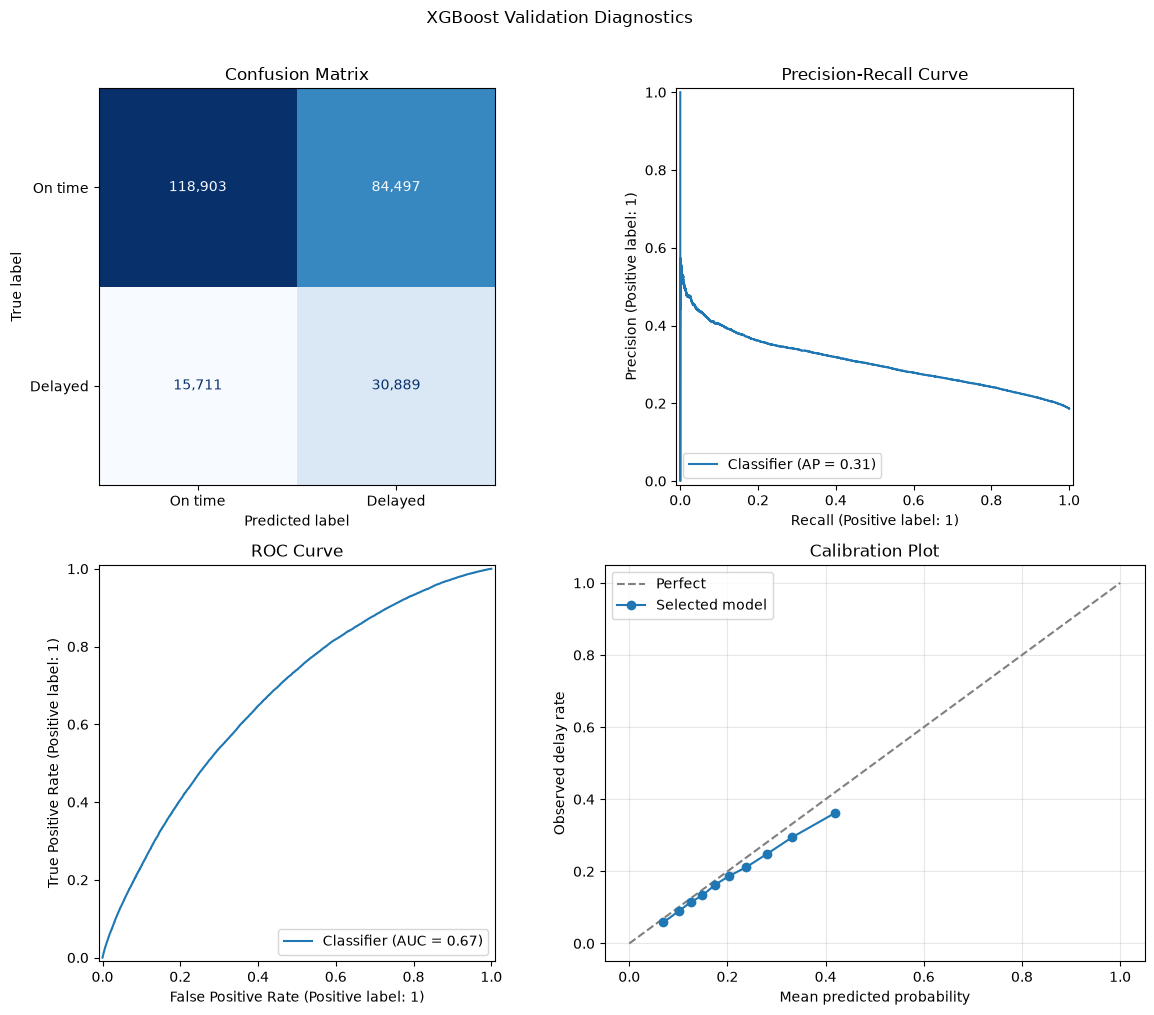

In [43]:
validation_labels = confirmation_data["y_validation"]
selected_predictions = (
    selected_probabilities >= selected_threshold
).astype(int)

figure, axes = plt.subplots(2, 2, figsize=(12, 10))
ConfusionMatrixDisplay.from_predictions(
    validation_labels,
    selected_predictions,
    display_labels=["On time", "Delayed"],
    cmap="Blues",
    colorbar=False,
    values_format=",d",
    ax=axes[0, 0],
)
axes[0, 0].set_title("Confusion Matrix")

PrecisionRecallDisplay.from_predictions(
    validation_labels, selected_probabilities, ax=axes[0, 1]
)
axes[0, 1].set_title("Precision-Recall Curve")

RocCurveDisplay.from_predictions(
    validation_labels, selected_probabilities, ax=axes[1, 0]
)
axes[1, 0].set_title("ROC Curve")

observed, predicted = calibration_curve(
    validation_labels,
    selected_probabilities,
    n_bins=10,
    strategy="quantile",
)
axes[1, 1].plot([0, 1], [0, 1], "--", color="gray", label="Perfect")
axes[1, 1].plot(predicted, observed, marker="o", label="Selected model")
axes[1, 1].set_xlabel("Mean predicted probability")
axes[1, 1].set_ylabel("Observed delay rate")
axes[1, 1].set_title("Calibration Plot")
axes[1, 1].legend()
axes[1, 1].grid(alpha=0.3)

figure.suptitle(
    f"{selected_candidate['MODEL']} Validation Diagnostics", y=1.01
)
figure.tight_layout()
plt.show()


## Threshold Trade-Off


In [44]:
threshold_results = selected_artifacts["threshold_results"]
nearby_thresholds = threshold_results[
    threshold_results["THRESHOLD"].between(
        max(cfg.MODEL_SELECTION_THRESHOLD_MIN, selected_threshold - 0.10),
        min(cfg.MODEL_SELECTION_THRESHOLD_MAX, selected_threshold + 0.10),
    )
][
    [
        "THRESHOLD",
        "DELAY_PRECISION",
        "DELAY_RECALL",
        "DELAY_F1",
        "ACCURACY",
        "ALERT_RATE",
    ]
]
display(nearby_thresholds)


,THRESHOLD,DELAY_PRECISION,DELAY_RECALL,DELAY_F1,ACCURACY,ALERT_RATE
5,0.10,0.206512,0.947597,0.339119,0.311552,0.855312
6,0.11,0.212152,0.928734,0.345403,0.343832,0.816000
7,0.12,0.217932,0.905343,0.351300,0.376760,0.774352
8,0.13,0.224105,0.878627,0.357122,0.410352,0.730800
9,0.14,0.230600,0.850258,0.362804,0.443292,0.687284
10,0.15,0.237283,0.822039,0.368266,0.474296,0.645760
11,0.16,0.243685,0.791996,0.372696,0.503040,0.605816
12,0.17,0.249901,0.760515,0.376189,0.529856,0.567264
13,0.18,0.255714,0.727446,0.378409,0.554528,0.530264
14,0.19,0.261682,0.694850,0.380185,0.577688,0.494952


## Persist Reproducible Modeling Results


In [45]:
def write_pandas_table(frame: pd.DataFrame, table_name: str) -> None:
    clean = frame.copy()
    for column in clean.select_dtypes(include=["object"]).columns:
        clean[column] = clean[column].fillna("").astype(str)
    spark.createDataFrame(clean).write.format("delta").mode("overwrite").option(
        "overwriteSchema", "true"
    ).saveAsTable(table_name)


write_pandas_table(
    baseline_results,
    cfg.BASELINE_MODEL_COMPARISON_TABLE,
)
write_pandas_table(
    cv_results,
    cfg.TUNED_MODEL_COMPARISON_TABLE,
)
write_pandas_table(
    finalist_results,
    cfg.FINALIST_MODEL_COMPARISON_TABLE,
)

candidate_payload = {
    "selected_model": selected_candidate["MODEL"],
    "configuration_id": selected_candidate["CONFIGURATION_ID"],
    "interpretability": selected_candidate["INTERPRETABILITY"],
    "parameters": json.loads(selected_candidate["PARAMETERS"]),
    "decision_threshold": selected_threshold,
    "selection_rule": selection_rule,
    "validation_metrics": {
        metric: float(selected_candidate[metric])
        for metric in [
            "ACCURACY",
            "DELAY_PRECISION",
            "DELAY_RECALL",
            "DELAY_F1",
            "ROC_AUC",
            "PR_AUC",
            "BRIER_SCORE",
            "TOP_10_RECALL",
            "TOP_10_LIFT",
            "ALERT_RATE",
        ]
    },
    "training_period": "2025-01-01 to 2025-08-31",
    "validation_period": "2025-09-01 to 2025-10-31",
    "holdout_period": "2025-11-01 onward; not evaluated in Notebook 07",
    "random_seed": cfg.RANDOM_SEED,
}
feature_payload = {
    "categorical_features": CATEGORICAL_COLUMNS,
    "numerical_features": NUMERICAL_COLUMNS,
    "target": TARGET_COLUMN,
    "preprocessing": {
        "categorical": "OneHotEncoder(handle_unknown='ignore', min_frequency=20)",
        "numerical": "Median imputation followed by StandardScaler",
    },
    "historical_rate_rule": (
        "Training rows use strictly earlier dates; validation rows use only "
        "the preceding training period."
    ),
}


def write_json_artifact(path: str, payload: dict) -> None:
    content = json.dumps(payload, indent=2, sort_keys=True).encode("utf-8")
    try:
        dbutils.fs.put(path, content.decode("utf-8"), True)
    except NameError:
        from databricks.sdk import WorkspaceClient

        client = WorkspaceClient(
            profile=os.getenv("DATABRICKS_CONFIG_PROFILE", "capstone-serverless")
        )
        client.files.upload(path, io.BytesIO(content), overwrite=True)


write_json_artifact(cfg.CANDIDATE_SELECTION_PATH, candidate_payload)
write_json_artifact(cfg.MODEL_FEATURE_MANIFEST_PATH, feature_payload)

print(f"Baseline results: {cfg.BASELINE_MODEL_COMPARISON_TABLE}")
print(f"Cross-validation results: {cfg.TUNED_MODEL_COMPARISON_TABLE}")
print(f"Finalist results: {cfg.FINALIST_MODEL_COMPARISON_TABLE}")
print(f"Candidate metadata: {cfg.CANDIDATE_SELECTION_PATH}")
print(f"Feature manifest: {cfg.MODEL_FEATURE_MANIFEST_PATH}")


Baseline results: workspace.default.flight_delay_baseline_model_comparison
Cross-validation results: workspace.default.flight_delay_tuned_model_comparison
Finalist results: workspace.default.flight_delay_finalist_model_comparison
Candidate metadata: /Volumes/workspace/default/flight_delay_capstone/models/candidate_model_selection.json
Feature manifest: /Volumes/workspace/default/flight_delay_capstone/models/model_feature_manifest.json


## Completion Criteria

Notebook 07 is complete when:

- four baseline results and confusion matrices are reported;
- every tuned configuration has five chronological-fold results;
- broad and focused searches finish for all three algorithms;
- the finalist table includes all three algorithms;
- one threshold and candidate model are selected by the documented rule;
- the calibration, PR, ROC, and confusion-matrix diagnostics are shown;
- the comparison tables and JSON metadata are saved successfully; and
- no November-December outcome has been used.
